24BAD010-ANUSRI

Explained Variance Ratio:
PC1: 0.7277
PC2: 0.2303
PC3: 0.0368
PC4: 0.0052

Cumulative Variance:
PC1: 0.7277
PC2: 0.9580
PC3: 0.9948
PC4: 1.0000

Evaluation Metrics:

  Principal Component  Explained Variance Ratio  Cumulative Variance
0                 PC1                  0.727705             0.727705
1                 PC2                  0.230305             0.958010
2                 PC3                  0.036838             0.994848
3                 PC4                  0.005152             1.000000


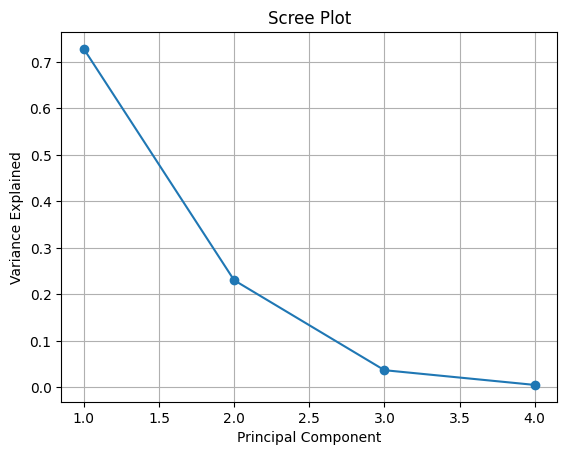

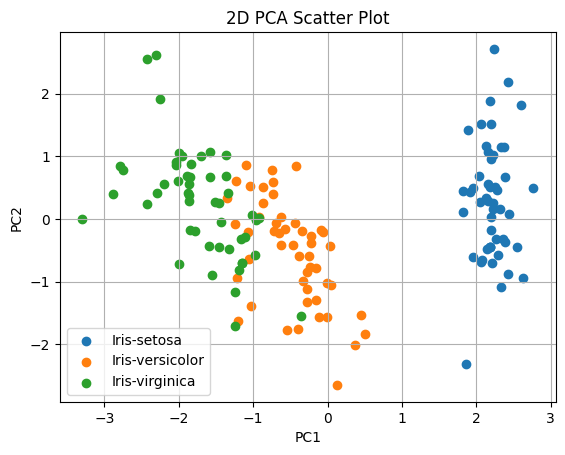

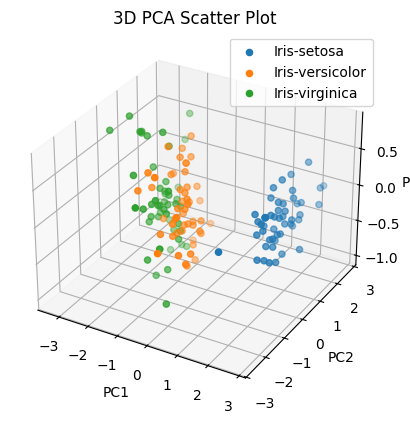

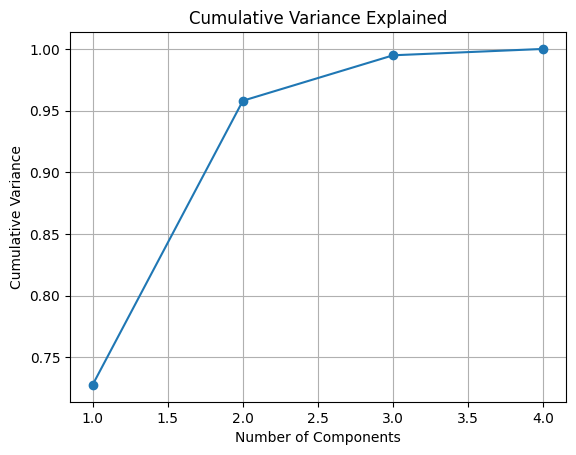

In [2]:
print("24BAD010-ANUSRI")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
cols = ['sepal_length','sepal_width','petal_length','petal_width','class']
df = pd.read_csv(url, names=cols, header=None)

df.dropna(inplace=True)

X = df.iloc[:, 0:4].astype(float).values
y = df['class'].values

X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0, ddof=1)
X_scaled = (X - X_mean) / X_std

cov_matrix = np.cov(X_scaled.T)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_index = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

X_pca_2D = X_scaled.dot(eigenvectors[:, :2])
X_pca_3D = X_scaled.dot(eigenvectors[:, :3])

print("\nExplained Variance Ratio:")
for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i}: {var:.4f}")

print("\nCumulative Variance:")
for i, var in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {var:.4f}")

metrics_df = pd.DataFrame({
    "Principal Component": [f"PC{i}" for i in range(1, len(explained_variance)+1)],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Variance": cumulative_variance
})

print("\nEvaluation Metrics:\n")
print(metrics_df)

plt.figure()
plt.plot(range(1, len(eigenvalues)+1), explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Scree Plot")
plt.grid()
plt.show()

plt.figure()
for label in np.unique(y):
    plt.scatter(X_pca_2D[y == label, 0],
                X_pca_2D[y == label, 1],
                label=label)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Scatter Plot")
plt.legend()
plt.grid()
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for label in np.unique(y):
    ax.scatter(X_pca_3D[y == label, 0],
               X_pca_3D[y == label, 1],
               X_pca_3D[y == label, 2],
               label=label)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Scatter Plot")
ax.legend()
plt.show()

plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Variance Explained")
plt.grid()
plt.show()

Anusri T: 24BAD010
   antecedents          consequents   support  confidence      lift
0  (UHT-milk,)  (other vegetables,)  0.038994    0.496732  1.318979
1  (UHT-milk,)        (rolls/buns,)  0.031042    0.395425  1.130863
2  (UHT-milk,)              (soda,)  0.027450    0.349673  1.115406
3  (UHT-milk,)        (whole milk,)  0.040534    0.516340  1.126928
4      (beef,)  (other vegetables,)  0.050795    0.424893  1.128223


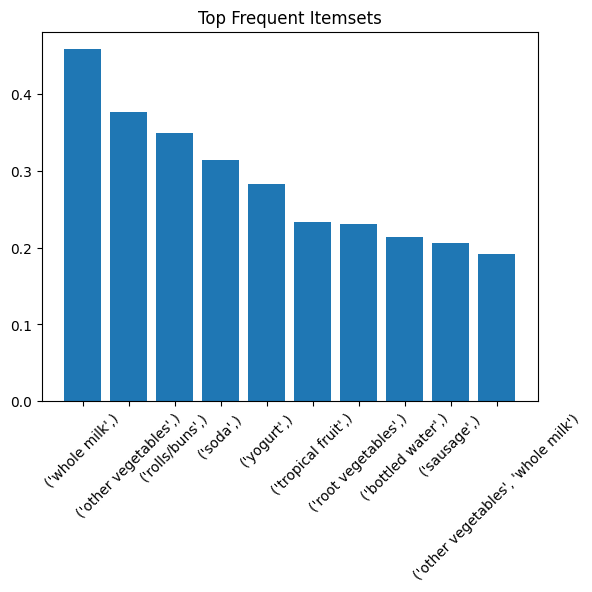

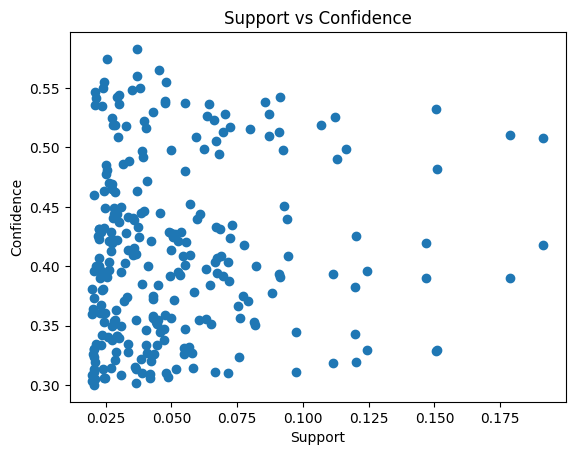

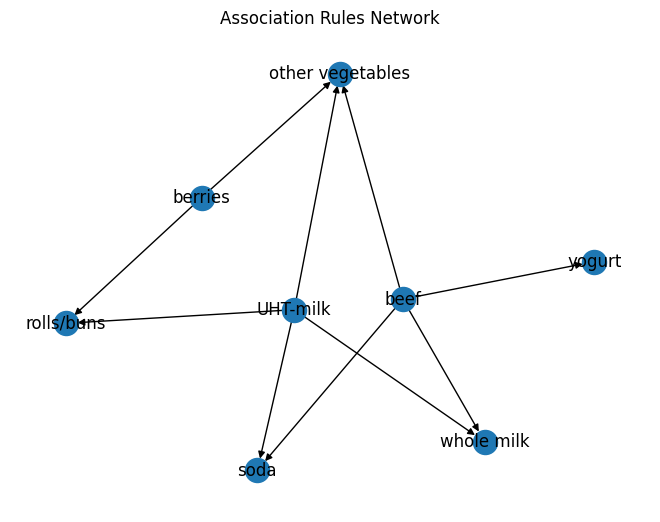

586
267


In [1]:
print("Anusri T: 24BAD010")
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from collections import Counter
import networkx as nx
data = pd.read_csv(r"C:\Users\anusr\Downloads\Groceries_dataset.csv (1)\Groceries_dataset.csv")
transactions = data.groupby('Member_number')['itemDescription'].apply(list).tolist()
total_transactions = len(transactions)
def get_support(itemset):
    count = 0
    for t in transactions:
        if set(itemset).issubset(set(t)):
            count += 1
    return count / total_transactions
items = sorted(set(item for t in transactions for item in t))
min_support = 0.02
frequent_itemsets = {}
for i in range(1, 3):
    for combo in itertools.combinations(items, i):
        sup = get_support(combo)
        if sup >= min_support:
            frequent_itemsets[combo] = sup
rules = []
for itemset in frequent_itemsets:
    if len(itemset) > 1:
        for i in range(1, len(itemset)):
            for antecedent in itertools.combinations(itemset, i):
                consequent = tuple(set(itemset) - set(antecedent))
                sup_itemset = frequent_itemsets[itemset]
                sup_ante = frequent_itemsets.get(antecedent, get_support(antecedent))
                sup_cons = frequent_itemsets.get(consequent, get_support(consequent))
                confidence = sup_itemset / sup_ante
                lift = confidence / sup_cons
                if confidence >= 0.3 and lift > 1:
                    rules.append((antecedent, consequent, sup_itemset, confidence, lift))
rules_df = pd.DataFrame(rules, columns=['antecedents', 'consequents', 'support', 'confidence', 'lift'])
print(rules_df.head())
top_items = sorted(frequent_itemsets.items(), key=lambda x: x[1], reverse=True)[:10]
plt.figure()
plt.bar(range(len(top_items)), [x[1] for x in top_items])
plt.xticks(range(len(top_items)), [str(x[0]) for x in top_items], rotation=45)
plt.title("Top Frequent Itemsets")
plt.show()
plt.figure()
plt.scatter(rules_df['support'], rules_df['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()
G = nx.DiGraph()
for _, row in rules_df.head(10).iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c)
plt.figure()
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
plt.title("Association Rules Network")
plt.show()
print(len(frequent_itemsets))
print(len(rules_df))